In [1]:
# Just NumPy and Matplotlib
import numpy as np
import matplotlib.pyplot as plt

## Normal equation

Let's set up the general problem: we have a simple dataset $x-y(x)$ and we want to fit it using a linear model:

$$
    \theta_0 + \theta_1 \, f_1(x) + \theta_2 \, f_2(x) + \dots + \theta_{d - 1} \, f_{d - 1}(x)
$$

In compact form:

$$
    \sum_{k = 0}^{d - 1} \, \theta_{k} \, f_{k}(x) \qquad f_0(x) := 1
$$

The loss function is the sum of squared residuals:

$$
    \sum_{j = 0}^{N - 1} \, \left( y_j - \sum_{k = 0}^{d - 1} \, \theta_{k} \, f_{k}(x_j) \right) ^ 2
$$

Let $\mathcal{X}$ (Design Matrix or Jacobian Matrix) be an $N \times d$ matrix where the entry in row $j$, column $k$ is:

$$
    \mathcal{X_{j,k}} = f_k(x_j) \qquad (j = 0,\dots,N-1; \ k = 0,\dots,d-1)
$$

Define the vectors:

$$
    \vec{\theta} = (\theta_0, \, \theta_1, \, \dots, \, \theta_{d-1})^t \qquad \text{(column vector of size d)}
$$

And:

$$
    \vec{y} = (y_0, \, y_1, \, \dots, \, y_{N-1})^t \quad \text{(column vector of size N})
$$

The sum of squared residuals can be written in vectorial form:

$$
    \| \vec{y} - \mathcal{X} \, \vec{\theta} \|^2
$$

By minimizing it, we obtain the optimal parameters of the linear model:

$$
    \vec{\theta} = \left( \mathcal{X}^{t} \, \mathcal{X} \right)^{-1} \, \mathcal{X}^{t} \, \vec{y}
$$

This is called the normal equation.

This matrix:

$$
    \mathcal{X}^{t} \, \mathcal{X}
$$

Is known as the Gram Matrix, and it's really important (we'll see why). It must be invertible to solve the general linear OLS problem.

Let's apply the normal equation for a straight fit and for a polynomial fit.

### Hooke's law

In [2]:
# Real dataset: https://computerapplicationshookeslaw.wordpress.com/
x = np.array([2.26, 4.32, 6.37, 8.43, 10.49, 12.55, 14.61, 16.67, 18.72], dtype = np.float32) # millimeters
F = np.arange(1.0, 10.0, 1, dtype = np.float32) # Newton

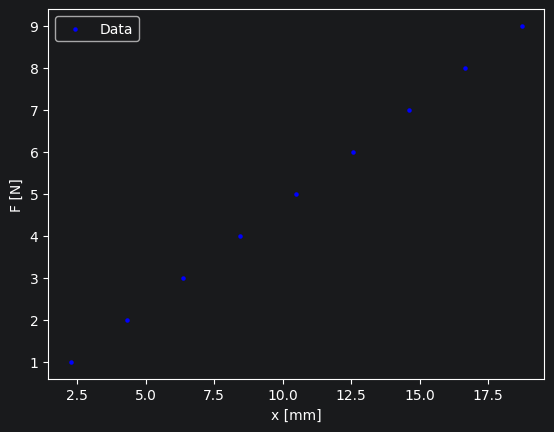

In [3]:
# Fast plot
plt.scatter(x, F, color = 'blue', label = 'Data', s = 5)
plt.xlabel('x [mm]')
plt.ylabel('F [N]')
plt.legend(loc = 'best')
plt.show()

Let's build the Design Matrix. The linear model is very simple:

$$
    y = k \, x + q
$$

Where $k$ and $q$ are unknown. $\mathcal{X}$ is very simple. Its $j$-row is just:

$$
    \mathcal{X}_{j,:} = \left( 1 \quad \, x_j \right)
$$

We can build it using NumPy

In [4]:
# Computing X
X = np.column_stack((np.ones_like(x), x))
X

array([[ 1.  ,  2.26],
       [ 1.  ,  4.32],
       [ 1.  ,  6.37],
       [ 1.  ,  8.43],
       [ 1.  , 10.49],
       [ 1.  , 12.55],
       [ 1.  , 14.61],
       [ 1.  , 16.67],
       [ 1.  , 18.72]], dtype=float32)

Now, let's apply the normal equation to get $k$ and $q$

In [5]:
# Computing Gram matrix
gram = X.T @ X
gram

array([[   9.      ,   94.420006],
       [  94.420006, 1244.7338  ]], dtype=float32)

In [6]:
# Check: is the gram matrix invertible?
np.linalg.det(gram)

np.float32(2287.4663)

In [7]:
# Compute k and q using the normal equation
gram_inv = (np.linalg.inv(gram))
q_opt, k_opt = (gram_inv @ X.T) @ F
q_opt, k_opt # q [N], k [N / mm]

(np.float32(-0.097307324), np.float32(0.48586932))

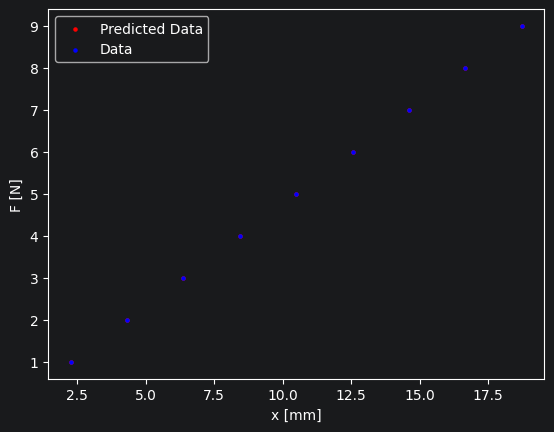

In [8]:
# Fast plot
plt.scatter(x, k_opt * x + q_opt, color = 'red', label = 'Predicted Data', s = 5)
plt.scatter(x, F, color = 'blue', label = 'Data', s = 5)
plt.xlabel('x [mm]')
plt.ylabel('F [N]')
plt.legend(loc = 'best')
plt.show()

We can compute the covariance matrix of estimated parameters as:

$$
    \mathcal{C} = \sigma ^ 2 \, \left(\mathcal{X}^{t} \, \mathcal{X}  \right)^{-1}
$$

Where $\sigma$ is given by:

$$
    \sigma ^ 2 = \frac{RSS}{N - d}
$$

$RSS$ is the minimized sum of squared residuals, $N$ is the total number of data for $x$ and $d$ is the number of parameters.


In [9]:
RSS = np.dot(F - k_opt * x - q_opt, F - k_opt * x - q_opt)
d = 2 # Because we have q and k
N = len(x)
sigma2 = RSS / (N - d)
Cov = sigma2 * gram_inv
Cov, RSS

(array([[ 1.6008165e-06, -1.2143086e-07],
        [-1.2143086e-07,  1.1574642e-08]], dtype=float32),
 np.float32(2.0592915e-05))

The diagonal of $\mathcal{C}$ provides estimated errors for $q$ and $k$

In [10]:
errq, errk = np.sqrt(np.diagonal(Cov))
errq, errk

(np.float32(0.0012652337), np.float32(0.00010758551))

### Constant Acceleration

In [11]:
# Real dataset here: https://ddl.stanford.edu/content/testing-constant-acceleration
t = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], dtype = np.float32) # s
speed = np.array([2.91, 3.63, 4.59, 5.56, 6.54, 7.53, 8.53, 9.51, 10.48, 11.47, 12.45, 13.43, 14.41, 15.39, 16.4, 17.37, 18.37, 19.35, 20.33, 21.35, 22.35, 23.37, 24.37, 25.33, 26.25], dtype = np.float32) # m/s
acc = np.array([-0.09, 0.76, 1.08, 0.92, 1, 0.92, 1.24, 1.04, 0.79, 1, 1.19, 0.73, 0.9, 0.89, 1.08, 1.46, 1.24, 0.77, 1.08, 0.66, 1.08, 1.26, 0.64, 0.44, 0.95], dtype = np.float32) # m / s^2

x = 0.5 * acc * t ** 2 + speed * t # Target vector. Messy for fun
x

array([  0.      ,   4.01    ,  11.34    ,  20.82    ,  34.16    ,
        49.15    ,  73.5     ,  92.05    , 109.119995, 143.73001 ,
       184.      , 191.89502 , 237.72    , 275.27502 , 335.44    ,
       424.80002 , 452.64    , 440.21503 , 540.9     , 524.78    ,
       663.      , 768.6     , 691.02    , 698.97003 , 903.6     ],
      dtype=float32)

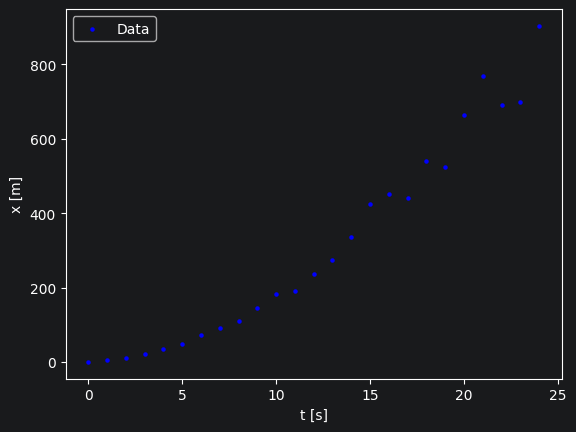

In [12]:
# Fast plot
plt.scatter(t, x, color = 'blue', label = 'Data', s = 5)
plt.xlabel('t [s]')
plt.ylabel('x [m]')
plt.legend(loc = 'best')
plt.show()

We wanna find $v$ and $a$ using the model:

$$
    x(t) = \frac{1}{2}\, a \, t ^ 2 + v_0 \, t
$$

Where $a$ and $v_0$ are unknown. The $j$-row of the Design Matrix is:

$$
    \mathcal{X}_{j,:} = \left( t_j \quad \frac{t_j ^ 2}{2} \right)
$$

In [13]:
# Design Matrix
X = np.column_stack((t, t ** 2 / 2))
X

array([[  0. ,   0. ],
       [  1. ,   0.5],
       [  2. ,   2. ],
       [  3. ,   4.5],
       [  4. ,   8. ],
       [  5. ,  12.5],
       [  6. ,  18. ],
       [  7. ,  24.5],
       [  8. ,  32. ],
       [  9. ,  40.5],
       [ 10. ,  50. ],
       [ 11. ,  60.5],
       [ 12. ,  72. ],
       [ 13. ,  84.5],
       [ 14. ,  98. ],
       [ 15. , 112.5],
       [ 16. , 128. ],
       [ 17. , 144.5],
       [ 18. , 162. ],
       [ 19. , 180.5],
       [ 20. , 200. ],
       [ 21. , 220.5],
       [ 22. , 242. ],
       [ 23. , 264.5],
       [ 24. , 288. ]], dtype=float32)

In [14]:
# Gram matrix
gram = X.T @ X
gram

array([[  4900.,  45000.],
       [ 45000., 440755.]], dtype=float32)

In [15]:
# Normal equation solution
gram_inv = np.linalg.inv(gram)
v_opt, a_opt = (gram_inv @ X.T) @ x
v_opt, a_opt # v [m / s], a [m / s^2]

(np.float32(5.510272), np.float32(2.5549338))

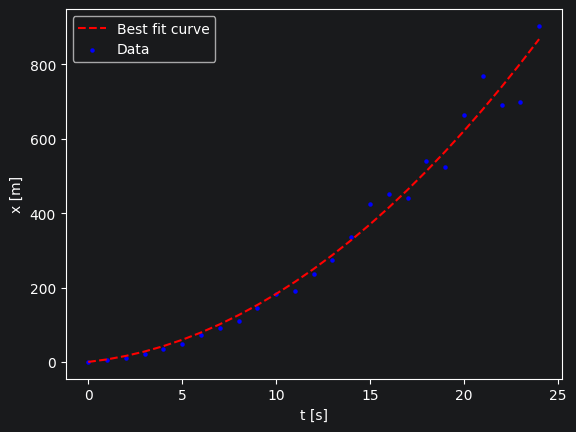

In [16]:
# Fast plot
plt.plot(t, 0.5 * a_opt * t ** 2 + v_opt * t, color = 'red', label = 'Best fit curve', linestyle = '--')
plt.scatter(t, x, color = 'blue', label = 'Data', s = 5)
plt.xlabel('t [s]')
plt.ylabel('x [m]')
plt.legend(loc = 'best')
plt.show()

Let's estimate errors for $v_0$ and $a$:

In [17]:
RSS = np.dot(x - (0.5 * a_opt * t ** 2 + v_opt * t), x - (0.5 * a_opt * t ** 2 + v_opt * t))
d = 2 # Because we have v_0 and k
N = len(t)
sigma2 = RSS / (N - d)
Cov = sigma2 * gram_inv
Cov, RSS

(array([[ 4.711503  , -0.48103285],
        [-0.48103285,  0.05237914]], dtype=float32),
 np.float32(33117.387))

In [18]:
errv, erra = np.sqrt(np.diagonal(Cov))
errv, erra

(np.float32(2.1705997), np.float32(0.22886488))